# Student Cost of Living in Prague
## Data Processing in Python 
Anna Chodurková, Barbora Motyková

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display, Math

In [111]:
import importlib
import source_code.loaders
importlib.reload(source_code.loaders)

<module 'source_code.loaders' from 'c:\\Users\\chodu\\Desktop\\midterm2026\\project\\source_code\\loaders.py'>

In [148]:
from source_code.loaders import (
    # Constants
    TRANSPORT_MONTHLY,
    LEISURE_MONTHLY,
    
    # Housing
    load_apartments,
    load_apartment_district_stats,
    load_apartments_clean,
    load_dorms,
    
    # Food
    load_canteen,
    load_groceries_basket,
    load_groceries_full
)

In [149]:
from source_code.cost_model import (
    build_scenario_table,
    get_cost_insights,
    get_affordable_options,
    compare_scenarios,
    compute_monthly_cost
)

### Overview model

In [115]:
df=build_scenario_table(canteen_days=5)

In [116]:
df_sorted = df.sort_values("total")
df_sorted

,housing,canteen,groceries,transport,leisure,total,type
label,,,,,,,
Dorm 4-bed (shared facilities),3765.000000,2520.8,3549.6,106.666667,2000,11942.066667,dorm
Dorm 3-bed (own facilities),3975.000000,2520.8,3549.6,106.666667,2000,12152.066667,dorm
Dorm 3-bed (shared facilities),4087.500000,2520.8,3549.6,106.666667,2000,12264.566667,dorm
Dorm 2-bed (shared facilities),4815.000000,2520.8,3549.6,106.666667,2000,12992.066667,dorm
Dorm 2-bed (own facilities),5910.000000,2520.8,3549.6,106.666667,2000,14087.066667,dorm
Dorm 1-bed (shared facilities),6120.000000,2520.8,3549.6,106.666667,2000,14297.066667,dorm
Dorm 1-bed (own facilities),8035.000000,2520.8,3549.6,106.666667,2000,16212.066667,dorm
Flat 3+KK outer_or_suburbs,10536.373333,2520.8,3549.6,106.666667,2000,18713.440000,apartment
Flat 3+KK inner_city,11940.160256,2520.8,3549.6,106.666667,2000,20117.226923,apartment


<Axes: ylabel='label'>

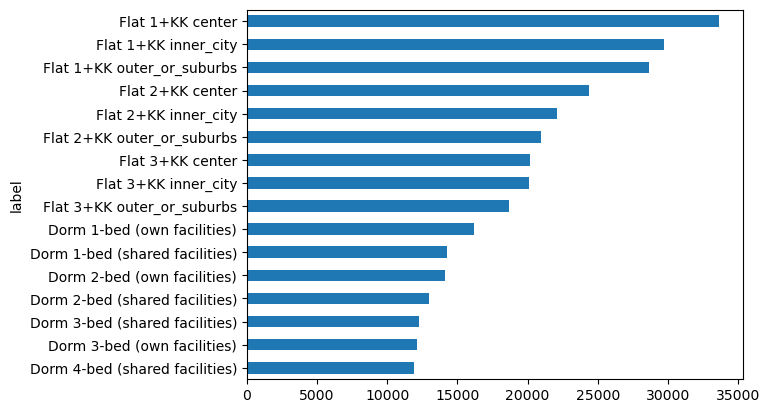

In [117]:
df_sorted["total"].plot.barh()

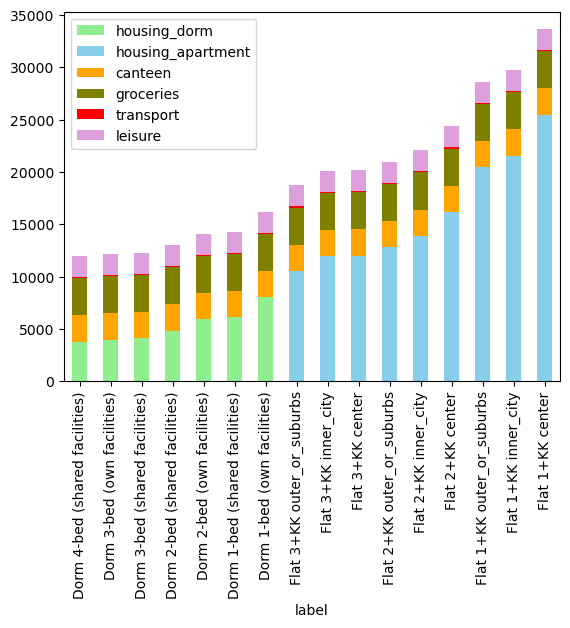

In [118]:
parts=["housing_dorm","housing_apartment","canteen","groceries","transport","leisure"]

df_sorted["housing_dorm"] =df_sorted["housing"].where(df_sorted["type"]=="dorm", 0)
df_sorted["housing_apartment"] =df_sorted["housing"].where(df_sorted["type"]=="apartment", 0)

colors={
    "housing_dorm":"lightgreen",
    "housing_apartment":"skyblue",
    "canteen":"orange",
    "groceries":"olive",
    "transport":"red",
    "leisure":"plum"}

df_sorted[parts].plot.bar(stacked=True,color=[colors[p]for p in parts])
plt.savefig("figures/total_costs.png",bbox_inches="tight")
plt.show()

# Housing analysis 


In [119]:
apartments = load_apartments_clean()
district_stats = load_apartment_district_stats()
dorms = load_dorms()

In [120]:
apartments

,price,charges,surface,disposition,address,district,full_cost,disposition_clean,price_per_m2,zone
0,16100,3100,33,DISP_1_KK,"Federova, Praha - Kyje",Kyje,19200,1+KK,581.818182,outer_or_suburbs
1,40621,7168,40,NaN,"Starokošířská, Praha - Košíře",Košíře,47789,unknown,1194.725000,inner_city
2,28000,6000,80,DISP_3_KK,"Amforova, Praha - Stodůlky",Stodůlky,34000,3+KK,425.000000,outer_or_suburbs
3,15990,0,33,DISP_1_KK,"Freyova, Praha - Vysočany",Vysočany,15990,1+KK,484.545455,inner_city
4,24500,3000,51,DISP_2_1,"náměstí Josefa Machka, Praha - Košíře",Košíře,27500,2+1,539.215686,inner_city
...,...,...,...,...,...,...,...,...,...,...
1226,34900,12049,71,DISP_3_1,"Francouzská, Praha - Vinohrady",Vinohrady,46949,3+1,661.253521,inner_city
1227,31987,5645,31,NaN,"Kmochova, Praha - Smíchov",Smíchov,37632,unknown,1213.935484,inner_city
1228,23000,4000,42,DISP_2_KK,"Podplukovníka Sochora, Praha - Holešovice",Holešovice,27000,2+KK,642.857143,inner_city
1229,19000,3500,43,DISP_2_KK,"Nad Kolonií, Praha - Podolí",Podolí,22500,2+KK,523.255814,inner_city


In [121]:
district_stats

,zone,disposition_clean,avg_rent,avg_m2_price,count
0,center,1+1,22566.666667,687.672533,3
1,center,1+KK,25472.857143,976.291126,7
2,center,2+1,32422.222222,493.355657,9
3,center,2+KK,32351.250000,718.018330,8
4,center,3+1,35800.000000,421.176471,1
5,center,3+KK,36000.000000,500.000000,3
6,center,unknown,45610.200000,1390.823892,15
7,inner_city,1+1,21398.333333,545.719975,36
8,inner_city,1+KK,21562.980892,706.096441,157
9,inner_city,2+1,27749.073171,469.820999,82


### 1. How affordable are apartments in Prague?

In [122]:
#create price categories
bins = [0,15000,25000,35000,60000]
labels=["very_cheap", "lower_student", "upper_student", "luxury"]

apartments["price_group"] = pd.cut(
    apartments["full_cost"],
    bins=bins,
    labels=labels)

In [123]:
apartments["price_group"].value_counts(normalize=True)*100


price_group
upper_student    39.967506
lower_student    38.830219
luxury           17.140536
very_cheap        4.061738
Name: proportion, dtype: float64

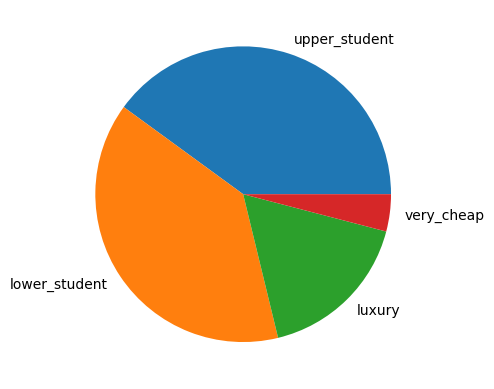

In [124]:
counts=apartments["price_group"].value_counts()
plt.pie(counts,labels=counts.index)
plt.show()

1.
Only 4% of apartments fall into very cheap category (under 15000)   
Majority of appartments fall into the lower_student and upper_student categories

### 2. Does location affect apartment prices?

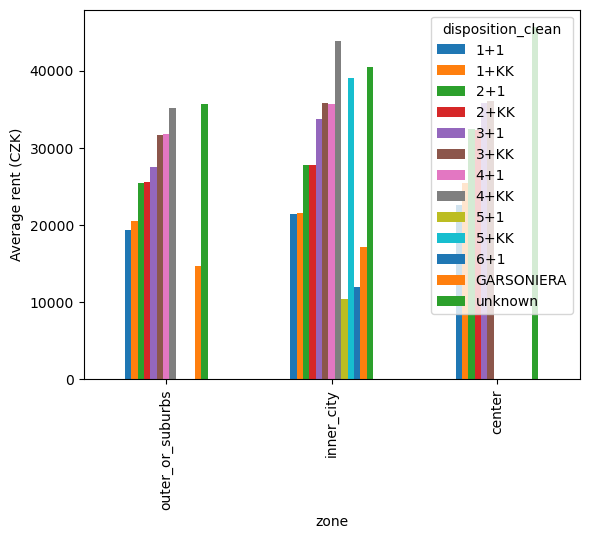

In [125]:
pivot = district_stats.pivot(index="zone", columns="disposition_clean", values="avg_rent")

# sort rows by overall average rent across zones
pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]

pivot.plot.bar()

plt.ylabel("Average rent (CZK)")
plt.show()

In [126]:
pd.crosstab(apartments["zone"],apartments["price_group"],normalize="index")

price_group,very_cheap,lower_student,upper_student,luxury
zone,,,,
center,0.000000,0.108696,0.478261,0.413043
inner_city,0.034621,0.347537,0.415446,0.202397
outer_or_suburbs,0.055300,0.488479,0.364055,0.092166


2.  
Luxury and upper_student apartments are concentrated in the center   
Outer districs contain a larger proportion of affordable housing 

### 3. Which apartment type provides the best value?

In [127]:
district_stats.sort_values("avg_m2_price")[["zone", "disposition_clean", "avg_m2_price"]]


,zone,disposition_clean,avg_m2_price
17,inner_city,6+1,92.307692
15,inner_city,5+1,122.364706
26,outer_or_suburbs,4+1,302.726352
27,outer_or_suburbs,4+KK,334.415775
24,outer_or_suburbs,3+1,349.010886
13,inner_city,4+1,383.336364
11,inner_city,3+1,403.396254
4,center,3+1,421.176471
25,outer_or_suburbs,3+KK,425.715397
14,inner_city,4+KK,432.319556


In [128]:
zone_means = district_stats.groupby("zone")["avg_m2_price"].mean()
zone_effect = zone_means.var()
size_means = district_stats.groupby("disposition_clean")["avg_m2_price"].mean()
size_effect = size_means.var()
print(f"Zone effect: {zone_effect} \nSize effect: {size_effect}")


Zone effect: 19640.596116703622 
Size effect: 72549.85880830267


In [129]:
print("Zone effect:", zone_effect)
print("Size effect:", size_effect)

Zone effect: 19640.596116703622
Size effect: 72549.85880830267


3.1 Apartment size/layout matters more than location for price per m2

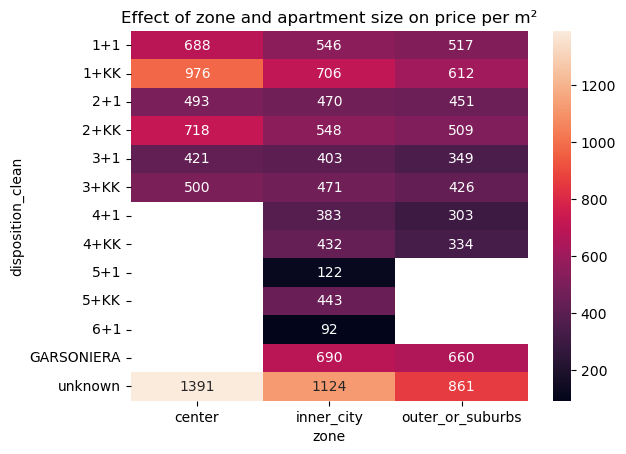

In [130]:
pivot = district_stats.pivot(
    index="disposition_clean",
    columns="zone",
    values="avg_m2_price"
)

sns.heatmap(pivot,annot=True,fmt=".0f")
plt.title("Effect of zone and apartment size on price per m²")
plt.show()

3.2   
Apartments in the center have higher prices, while suburban areas are cheaper  

Smaller apartments are signigicantly more expensive per m2 than larger apartments, regrdless of location

interaction effect:   
Small apartments benefit more from central location   
Large apartments lose value efficiency even in good location

### 4. Is sharing accommodation worthwhile?

In [131]:
apartments

,price,charges,surface,disposition,address,district,full_cost,disposition_clean,price_per_m2,zone,price_group
0,16100,3100,33,DISP_1_KK,"Federova, Praha - Kyje",Kyje,19200,1+KK,581.818182,outer_or_suburbs,lower_student
1,40621,7168,40,NaN,"Starokošířská, Praha - Košíře",Košíře,47789,unknown,1194.725000,inner_city,luxury
2,28000,6000,80,DISP_3_KK,"Amforova, Praha - Stodůlky",Stodůlky,34000,3+KK,425.000000,outer_or_suburbs,upper_student
3,15990,0,33,DISP_1_KK,"Freyova, Praha - Vysočany",Vysočany,15990,1+KK,484.545455,inner_city,lower_student
4,24500,3000,51,DISP_2_1,"náměstí Josefa Machka, Praha - Košíře",Košíře,27500,2+1,539.215686,inner_city,upper_student
...,...,...,...,...,...,...,...,...,...,...,...
1226,34900,12049,71,DISP_3_1,"Francouzská, Praha - Vinohrady",Vinohrady,46949,3+1,661.253521,inner_city,luxury
1227,31987,5645,31,NaN,"Kmochova, Praha - Smíchov",Smíchov,37632,unknown,1213.935484,inner_city,luxury
1228,23000,4000,42,DISP_2_KK,"Podplukovníka Sochora, Praha - Holešovice",Holešovice,27000,2+KK,642.857143,inner_city,upper_student
1229,19000,3500,43,DISP_2_KK,"Nad Kolonií, Praha - Podolí",Podolí,22500,2+KK,523.255814,inner_city,lower_student


In [132]:
sharing=apartments[apartments["disposition_clean"]!="unknown"].copy()

sharing["people"]=(
    sharing["disposition_clean"]
    .replace("GARSONIERA","1+KK")
    .str.split("+").str[0].astype(int)
)

In [133]:
sharing

,price,charges,surface,disposition,address,district,full_cost,disposition_clean,price_per_m2,zone,price_group,people
0,16100,3100,33,DISP_1_KK,"Federova, Praha - Kyje",Kyje,19200,1+KK,581.818182,outer_or_suburbs,lower_student,1
2,28000,6000,80,DISP_3_KK,"Amforova, Praha - Stodůlky",Stodůlky,34000,3+KK,425.000000,outer_or_suburbs,upper_student,3
3,15990,0,33,DISP_1_KK,"Freyova, Praha - Vysočany",Vysočany,15990,1+KK,484.545455,inner_city,lower_student,1
4,24500,3000,51,DISP_2_1,"náměstí Josefa Machka, Praha - Košíře",Košíře,27500,2+1,539.215686,inner_city,upper_student,2
6,14990,0,45,DISP_2_KK,"Donská, Praha - Vršovice",Vršovice,14990,2+KK,333.111111,inner_city,very_cheap,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1225,21000,3000,41,DISP_2_KK,"Vorařská, Praha - Modřany",Modřany,24000,2+KK,585.365854,outer_or_suburbs,lower_student,2
1226,34900,12049,71,DISP_3_1,"Francouzská, Praha - Vinohrady",Vinohrady,46949,3+1,661.253521,inner_city,luxury,3
1228,23000,4000,42,DISP_2_KK,"Podplukovníka Sochora, Praha - Holešovice",Holešovice,27000,2+KK,642.857143,inner_city,upper_student,2
1229,19000,3500,43,DISP_2_KK,"Nad Kolonií, Praha - Podolí",Podolí,22500,2+KK,523.255814,inner_city,lower_student,2


In [134]:
sharing["price_per_person"]=sharing["full_cost"]/sharing["people"]

In [135]:
groups=sharing.groupby("people")["price_per_person"].mean()
groups

people
1    20848.036723
2    13584.274225
3    10912.089820
4     9597.342593
5     4940.100000
6     2000.000000
Name: price_per_person, dtype: float64

In [136]:
baseline=groups.loc[1]

savings=baseline-groups
savings_pct=(savings/baseline)*100

In [137]:
sharing_stats=pd.DataFrame({
    "avg_cost_per_person":groups,
    "savings_czk": savings,
    "savings_pct": savings_pct
})
sharing_stats

,avg_cost_per_person,savings_czk,savings_pct
people,,,
1,20848.036723,0.000000,0.000000
2,13584.274225,7263.762498,34.841470
3,10912.089820,9935.946903,47.658909
4,9597.342593,11250.694131,53.965245
5,4940.100000,15907.936723,76.304244
6,2000.000000,18848.036723,90.406771


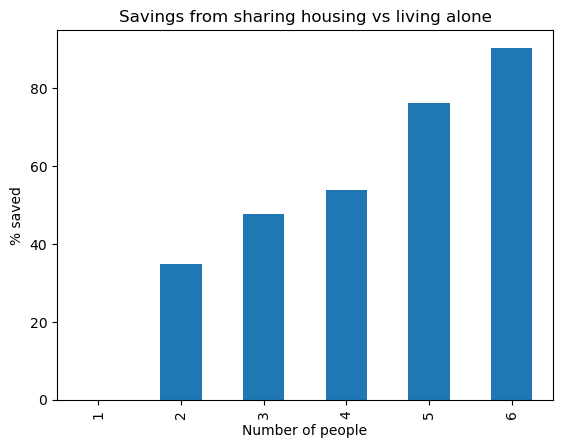

In [138]:
sharing_stats["savings_pct"].plot(kind="bar")
plt.title("Savings from sharing housing vs living alone")
plt.ylabel("% saved")
plt.xlabel("Number of people")
plt.show()

$$
\text{Total savings} =
\frac{cost_{\text{alone}} - cost_{\text{group}}}{cost_{\text{alone}}} \times 100
$$

$$
\text{Marginal change} =
\frac{cost_{\text{previous}} - cost_{\text{current}}}{cost_{\text{previous}}} \times 100
$$

In [139]:
for people, row in sharing_stats.iterrows():
    
    # baseline: living alone
    if people == 1:
        print(
            f"Living alone costs on average {row['avg_cost_per_person']:.0f} CZK per person."
        )
    
    else:
        prev_cost = sharing_stats.loc[people - 1, "avg_cost_per_person"]
        
        # marginal change vs previous group
        diff_pct = (prev_cost - row["avg_cost_per_person"]) / prev_cost * 100
        
        roommates = people - 1
        
        # main phrase (current group)
        if roommates == 1:
            phrase = "Sharing with 1 person"
        else:
            phrase = f"Sharing with {roommates} people"
        
        # previous group label (clean logic)
        if people - 1 == 1:
            prev_phrase = "living alone"
        else:
            prev_phrase = f"sharing with {people - 2} people"
        
        print(
            f"{phrase} costs on average {row['avg_cost_per_person']:.0f} CZK per person, "
            f"saving {row['savings_pct']:.1f}% compared to living alone "
            f"(decrease of {diff_pct:.1f}% compared to {prev_phrase})."
        )

Living alone costs on average 20848 CZK per person.
Sharing with 1 person costs on average 13584 CZK per person, saving 34.8% compared to living alone (decrease of 34.8% compared to living alone).
Sharing with 2 people costs on average 10912 CZK per person, saving 47.7% compared to living alone (decrease of 19.7% compared to sharing with 1 people).
Sharing with 3 people costs on average 9597 CZK per person, saving 54.0% compared to living alone (decrease of 12.0% compared to sharing with 2 people).
Sharing with 4 people costs on average 4940 CZK per person, saving 76.3% compared to living alone (decrease of 48.5% compared to sharing with 3 people).
Sharing with 5 people costs on average 2000 CZK per person, saving 90.4% compared to living alone (decrease of 59.5% compared to sharing with 4 people).


4.  
There is a strong inverse relationship between household size and monthly housing costs per person.     
Living alone is the most expensive option, with average monthly cost approximately 20 848 CZK.

Sharing housing significantly reduces per-person costs.   
The relationship is non-linear - the largest improvement occurs when moving from solo living to shared accommodation.   
Additional roomates continue to reduce costs, but with diminishing marginal effects.   

Strong initial cost reduction that flatten at higher household sizes.

### Food analysis 

1. Cost Breakdown

In [140]:
basket = load_groceries_basket()

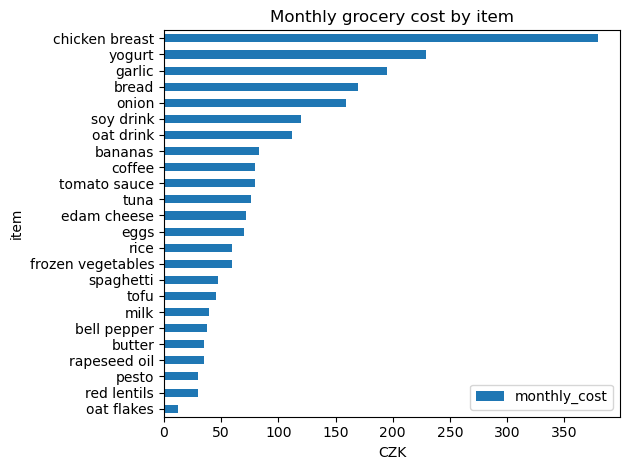

In [141]:
basket.sort_values("monthly_cost").plot.barh(x="item", y="monthly_cost")
plt.title("Monthly grocery cost by item")
plt.xlabel("CZK")
plt.tight_layout()
plt.show()

2. Store comparison 

In [142]:
basket["store"].value_counts()

store
billa     8
kosik     8
rohlik    5
lidl      3
Name: count, dtype: int64

In [143]:
groceries_full = load_groceries_full()
groceries_full.head()

,item_czech,item,billa_title,billa_price_czk,billa_packaging,billa_price_per_unit,lidl_title,lidl_price_czk,lidl_packaging,lidl_price_per_unit,kosik_title,kosik_price_czk,kosik_packaging,kosik_price_per_unit,rohlik_title,rohlik_price_czk,rohlik_packaging,rohlik_price_per_unit
0,banany,bananas,CORNY proteinová tyčinka 30% banán 50g,51.9,50 g,1.038000,NaN,NaN,NaN,NaN,"Banán, 1 ks",6.783,170.0 g,0.039900,Banán 1 ks,6.95,cca 190 g,0.036579
1,cervena_cocka,red lentils,BILLA Čočka červená 500g,29.9,500 g,0.059800,NaN,NaN,NaN,NaN,Fine Life Čočka červená,34.900,500.0 g,0.069800,Kitchin Červená čočka,33.90,500 g,0.067800
2,cesnek,garlic,"Česká Farma Česnek síťka, 200g",49.9,200 g,0.249500,Česnek,39.9,NaN,NaN,Česnek drcený porce,64.900,1.0 kg,0.064900,"Česnek ""ošklivák"" český, síť",69.90,350 g,0.199714
3,chleb,bread,"Chléb Chalupářský, 850g kulatý",58.9,850 g,0.069294,Dřevorubecký chléb,23.9,405 g,0.059012,Český pekař Chléb konzumní,42.500,1.2 kg,0.035417,Merhautovo pekařství Chléb žitný,35.90,400 g,0.089750
4,cibule,onion,"Česká Farma Cibule 1kg, síť",20.9,1 kg,0.020900,NaN,NaN,NaN,NaN,"Cibule žlutá, síť",19.900,1.0 kg,0.019900,"Cibule žlutá, síť",19.90,1 kg,0.019900


In [144]:
print("Missing prices per store:")
print(groceries_full[["billa_price_czk","lidl_price_czk",
                        "kosik_price_czk","rohlik_price_czk"]].isna().sum())

Missing prices per store:
billa_price_czk      0
lidl_price_czk      13
kosik_price_czk      0
rohlik_price_czk     0
dtype: int64


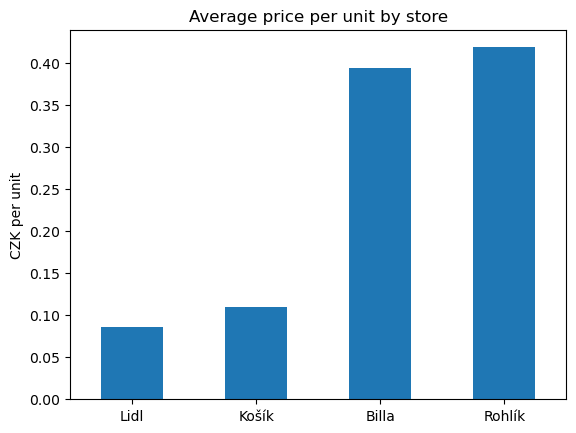

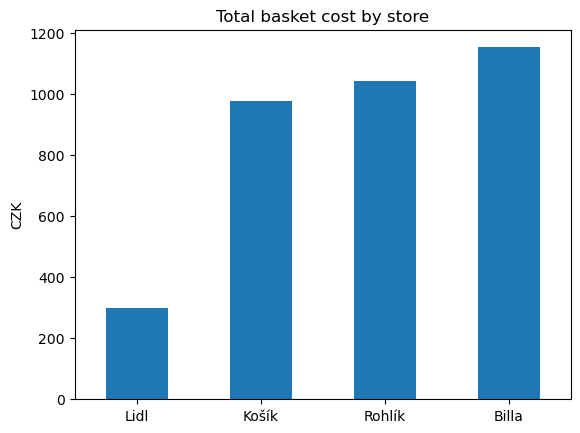

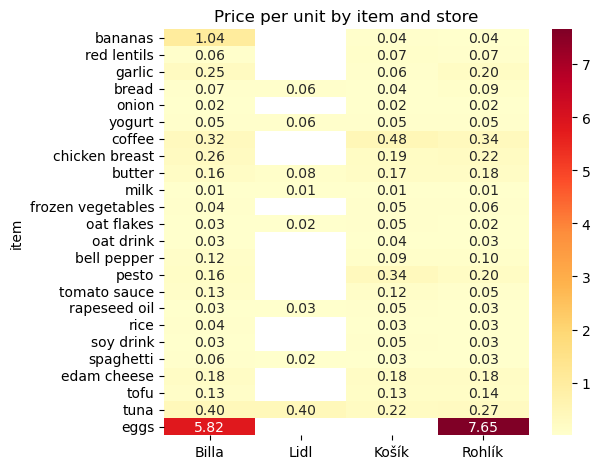

In [145]:
# Extract per-unit prices for each store
store_prices = groceries_full[["item", "billa_price_per_unit", "lidl_price_per_unit", 
                                "kosik_price_per_unit", "rohlik_price_per_unit"]].copy()
store_prices.columns = ["item", "Billa", "Lidl", "Košík", "Rohlík"]
store_prices = store_prices.set_index("item")

# Average price per unit across items (lower = cheaper store overall)
store_means = store_prices.mean()
store_means.sort_values().plot.bar()
plt.title("Average price per unit by store")
plt.ylabel("CZK per unit")
plt.xticks(rotation=0)
plt.show()

# Total basket cost per store (sum of czk prices)
basket_totals = groceries_full[["billa_price_czk", "lidl_price_czk", 
                                 "kosik_price_czk", "rohlik_price_czk"]].sum()
basket_totals.index = ["Billa", "Lidl", "Košík", "Rohlík"]
basket_totals.sort_values().plot.bar()
plt.title("Total basket cost by store")
plt.ylabel("CZK")
plt.xticks(rotation=0)
plt.show()

# Heatmap: which store is cheapest for each item?
sns.heatmap(store_prices, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Price per unit by item and store")
plt.tight_layout()
plt.show()

3. Canteen vs groceries

In [156]:
basket.head()

,item,unit_price,store,qty_per_month,monthly_cost
0,bananas,6.95,rohlik,12,83.4
1,red lentils,29.90,billa,1,29.9
2,garlic,64.90,kosik,3,194.7
3,bread,42.50,kosik,4,170.0
4,onion,19.90,kosik,8,159.2


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

basket_monthly = load_groceries_basket()["monthly_cost"].sum()

canteen = load_canteen()

lunch_share = 0.40

home_lunch_cost = basket_monthly * lunch_share
other_food_cost = basket_monthly * (1 - lunch_share)

results = []

for _, row in canteen.iterrows():

    days = row["days_per_week"]

    # Remaining lunches cooked at home
    home_lunch_remaining = home_lunch_cost * (5 - days) / 5

    total_food = (
        other_food_cost
        + home_lunch_remaining
        + row["monthly_cost"]
    )

    results.append({
        "days_per_week": days,
        "canteen_cost": row["monthly_cost"],
        "home_lunch_remaining": home_lunch_remaining,
        "total_food": total_food
    })

food_compare = pd.DataFrame(results)

food_compare["all_home"] = basket_monthly

food_compare["extra_cost_vs_home"] = (
    food_compare["total_food"] - food_compare["all_home"]
)
food_compare["extra_cost_pct"] = (
    food_compare["extra_cost_vs_home"] / food_compare["all_home"] * 100
)

print(food_compare)

   days_per_week  canteen_cost  home_lunch_remaining  total_food  all_home  \
0            1.0        504.16              721.9072   2579.6432   2255.96   
1            2.0       1008.32              541.4304   2903.3264   2255.96   
2            3.0       1512.48              360.9536   3227.0096   2255.96   
3            4.0       2016.64              180.4768   3550.6928   2255.96   
4            5.0       2520.80                0.0000   3874.3760   2255.96   

   extra_cost_vs_home  extra_cost_pct  
0            323.6832       14.347914  
1            647.3664       28.695828  
2            971.0496       43.043742  
3           1294.7328       57.391656  
4           1618.4160       71.739570  


In [204]:
baseline = food_compare["all_home"].iloc[0]

one_day = food_compare.loc[
    food_compare["days_per_week"] == 1,
    "extra_cost_vs_home"
].iloc[0]

five_day = food_compare.loc[
    food_compare["days_per_week"] == 5,
    "extra_cost_vs_home"
].iloc[0]

five_day_pct = food_compare.loc[
    food_compare["days_per_week"] == 5,
    "extra_cost_pct"
].iloc[0]

print(f"Monthly cost of preparing all meals at home: {baseline:.0f} CZK.")

print(
    f"Using the university canteen one day per week increases monthly food expenditure "
    f"by approximately {one_day:.0f} CZK compared to home cooking."
)

print(
    f"Using the university canteen five days per week increases monthly food expenditure "
    f"by approximately {five_day:.0f} CZK compared to home cooking."
)

print(
    f"This represents a {five_day_pct:.1f}% increase in monthly food spending "
    f"relative to the home-cooking baseline."
)

print(
    f"Therefore, the maximum potential saving from cooking at home instead of "
    f"eating at the canteen every weekday is approximately {five_day:.0f} CZK per month."
)

Monthly cost of preparing all meals at home: 2256 CZK.
Using the university canteen one day per week increases monthly food expenditure by approximately 324 CZK compared to home cooking.
Using the university canteen five days per week increases monthly food expenditure by approximately 1618 CZK compared to home cooking.
This represents a 71.7% increase in monthly food spending relative to the home-cooking baseline.
Therefore, the maximum potential saving from cooking at home instead of eating at the canteen every weekday is approximately 1618 CZK per month.


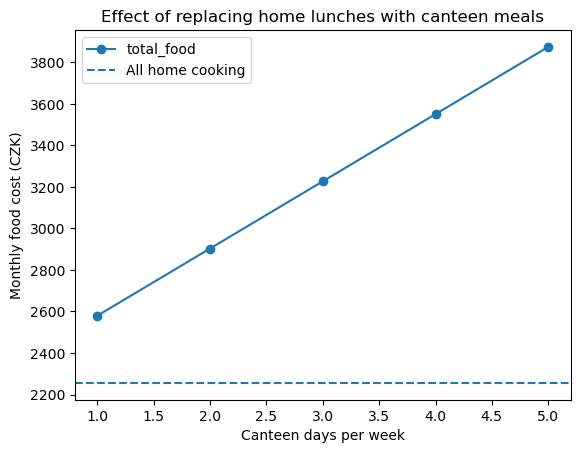

In [190]:
food_compare.set_index("days_per_week")[["total_food"]].plot(
    marker="o"
)

plt.axhline(
    basket_monthly,
    linestyle="--",
    label="All home cooking"
)

plt.title("Effect of replacing home lunches with canteen meals")
plt.ylabel("Monthly food cost (CZK)")
plt.xlabel("Canteen days per week")
plt.legend()
plt.show()

In [202]:
for lunch_share in [0.3, 0.5, 0.7]:
    print(f"\nLunch share = {lunch_share:.0%}")

    home_lunch_cost = basket_monthly * lunch_share
    other_food_cost = basket_monthly * (1 - lunch_share)

    for _, row in canteen.iterrows():
        days = row["days_per_week"]

        home_lunch_remaining = home_lunch_cost * (5 - days) / 5

        total_food = (
            other_food_cost
            + home_lunch_remaining
            + row["monthly_cost"]
        )

        print(
            f"{days} days/week: {total_food:.0f} CZK"
        )


Lunch share = 30%
1.0 days/week: 2625 CZK
2.0 days/week: 2994 CZK
3.0 days/week: 3362 CZK
4.0 days/week: 3731 CZK
5.0 days/week: 4100 CZK

Lunch share = 50%
1.0 days/week: 2535 CZK
2.0 days/week: 2813 CZK
3.0 days/week: 3092 CZK
4.0 days/week: 3370 CZK
5.0 days/week: 3649 CZK

Lunch share = 70%
1.0 days/week: 2444 CZK
2.0 days/week: 2633 CZK
3.0 days/week: 2821 CZK
4.0 days/week: 3009 CZK
5.0 days/week: 3198 CZK
